In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")

# Load our synthetic traffic dataset
df = pd.read_csv("../data/raw/synthetic_traffic_data.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 15)


,timestamp,segment_id,road_type,speed_limit,vehicle_count,congestion_level,average_speed,rainfall_mm,visibility_m,pothole_count,waterlogging,sudden_braking_events,hour_of_day,is_peak_hour,risk_score
0,2026-01-01 00:00:00,SEG_007,highway,80,114,0.30,53.13,30.861529,61.49,2,1,2,0,0,33.69
1,2026-01-01 01:00:00,SEG_015,city_road,50,107,0.31,32.40,0.000000,3588.94,7,0,2,1,0,29.90
2,2026-01-01 02:00:00,SEG_011,city_road,50,63,0.15,34.98,30.861529,61.49,3,0,1,2,0,20.42
3,2026-01-01 03:00:00,SEG_008,highway,80,297,0.66,27.83,0.000000,3588.94,2,0,1,3,0,30.88
4,2026-01-01 04:00:00,SEG_007,highway,80,190,0.50,40.15,0.000000,3588.94,1,0,1,4,0,26.24


In [2]:
# Display data types and non-null counts
print(df.info())

# Summary statistics for numerical columns
display(df.describe())

# Check for missing values
missing_counts = df.isnull().sum()
print("\nMissing Values per Column:\n", missing_counts[missing_counts > 0])

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              1000 non-null   str    
 1   segment_id             1000 non-null   str    
 2   road_type              1000 non-null   str    
 3   speed_limit            1000 non-null   int64  
 4   vehicle_count          1000 non-null   int64  
 5   congestion_level       1000 non-null   float64
 6   average_speed          1000 non-null   float64
 7   rainfall_mm            1000 non-null   float64
 8   visibility_m           1000 non-null   float64
 9   pothole_count          1000 non-null   int64  
 10  waterlogging           1000 non-null   int64  
 11  sudden_braking_events  1000 non-null   int64  
 12  hour_of_day            1000 non-null   int64  
 13  is_peak_hour           1000 non-null   int64  
 14  risk_score             1000 non-null   float64
dtypes: float64(5), i

,speed_limit,vehicle_count,congestion_level,average_speed,rainfall_mm,visibility_m,pothole_count,waterlogging,sudden_braking_events,hour_of_day,is_peak_hour,risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,68.480000,207.766000,0.521990,33.880910,9.011566,2558.924600,3.059000,0.187000,2.043000,11.436000,0.332000,35.27128
std,21.320041,109.459969,0.275671,21.713184,14.039213,1604.671639,1.812403,0.390107,1.455771,6.913009,0.471167,14.27834
min,40.000000,20.000000,0.000000,10.000000,0.000000,61.490000,0.000000,0.000000,0.000000,0.000000,0.000000,2.78000
25%,50.000000,115.500000,0.290000,14.790000,0.000000,61.490000,2.000000,0.000000,1.000000,5.000000,0.000000,24.05000
50%,80.000000,202.500000,0.510000,29.485000,0.000000,3588.940000,3.000000,0.000000,2.000000,11.000000,0.000000,34.78000
75%,80.000000,302.250000,0.760000,46.902500,30.861529,3588.940000,4.000000,0.000000,3.000000,17.000000,1.000000,44.96000
max,100.000000,399.000000,1.000000,106.780000,30.861529,3588.940000,11.000000,1.000000,8.000000,23.000000,1.000000,77.42000



Missing Values per Column:
 Series([], dtype: int64)


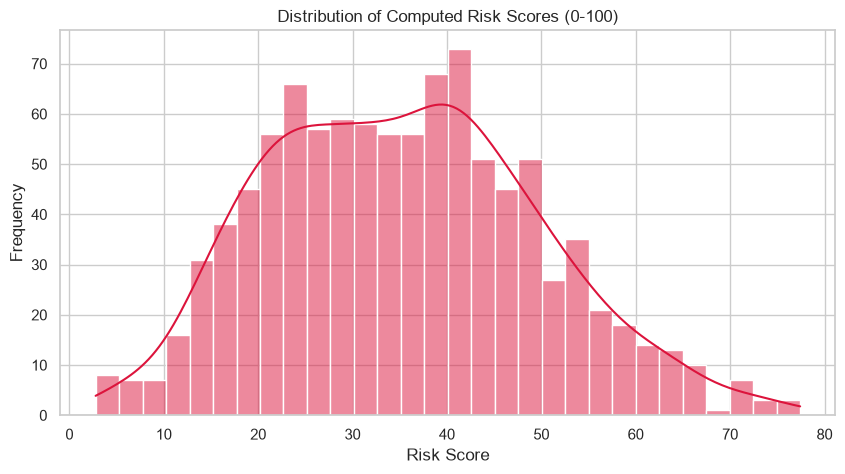

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['risk_score'], bins=30, kde=True, color='crimson')
plt.title("Distribution of Computed Risk Scores (0-100)")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

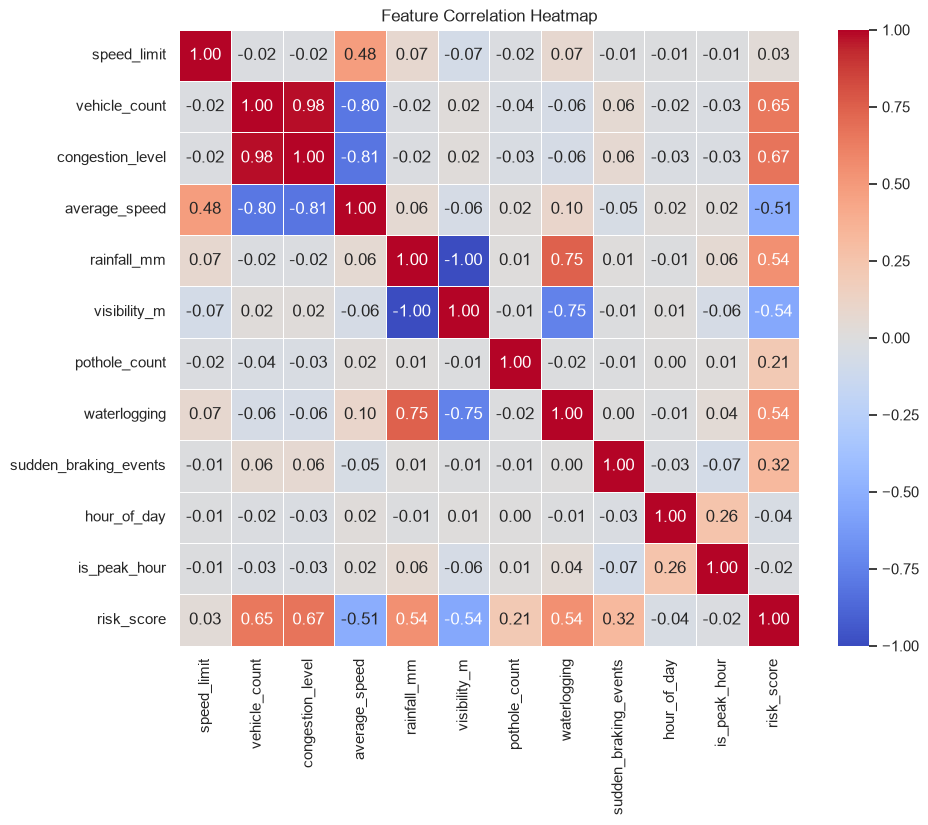

In [4]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()